# Sesión 6: Árboles de Regresión y Ajuste de Hiperparámetros

**Objetivos:**
- Entender el funcionamiento y la terminología de un Árbol de Decisión.
- **Visualizar el efecto** de los hiperparámetros clave (`max_depth`, `min_samples_leaf`...).
- Diagnosticar el **sobreajuste (overfitting)** y el **subajuste (underfitting)**.
- Ajustar hiperparámetros manualmente y de forma automática con `GridSearchCV`.
- Interpretar la importancia de las variables según el árbol.

## 1. ¿Qué es un Árbol de Decisión?

Un árbol de decisión aprende a predecir un valor haciendo una secuencia de preguntas simples sobre las características de los datos.



Es como un diagrama de flujo que divide los datos en grupos cada vez más pequeños y puros.

* **Nodo Raíz (Root Node)**: La primera pregunta que divide todo el conjunto de datos.
* **Nodo Interno (Internal Node)**: Una pregunta o condición sobre una característica.
* **Hoja (Leaf Node)**: Un nodo final que ya no se divide. Contiene la predicción final, que para regresión es el valor promedio de todas las muestras que han llegado a esa hoja.

## 2. Los "Tornillos" del Árbol: Visualizando Hiperparámetros

Antes de construir un árbol grande, vamos a entender sus piezas. Los **hiperparámetros** son las reglas que le damos al árbol para controlar cómo crece. ¡Vamos a verlos en acción!

### ¿Cómo funcionan estos hiperparámetros? ¡Veámoslo!

-   **`max_depth` (Profundidad Máxima):** Es la regla más simple. Controla cuántos niveles de "preguntas" puede tener el árbol.
    * **Observa en los gráficos de abajo:** El árbol con `max_depth=3` tiene una capa más de nodos que el de `max_depth=2`. Es más complejo y puede hacer distinciones más finas, pero también corre más riesgo de sobreajustar.

-   **`min_samples_split` (Muestras Mínimas para Dividir):** Esta regla le dice al árbol: "No te molestes en dividir un nodo si no tienes suficientes datos (muestras) en él".
    * **Observa en el gráfico:** Al poner `min_samples_split=50`, muchas ramas del árbol se detienen antes porque, aunque no han llegado a la profundidad máxima, el nodo ya tiene menos de 50 muestras y no se le permite seguir. Esto "poda" el árbol y lo simplifica.

-   **`min_samples_leaf` (Muestras Mínimas por Hoja):** Es una regla similar pero más sutil. Asegura que cada nodo hoja (la predicción final) esté basado en un número mínimo de ejemplos.
    * **Observa en el gráfico:** Con `min_samples_leaf=20`, las hojas finales son más "robustas". Esto evita que el árbol cree hojas para un grupito muy pequeño y específico de casas (que es la esencia del sobreajuste), forzando a que las predicciones sean el promedio de un grupo más general.

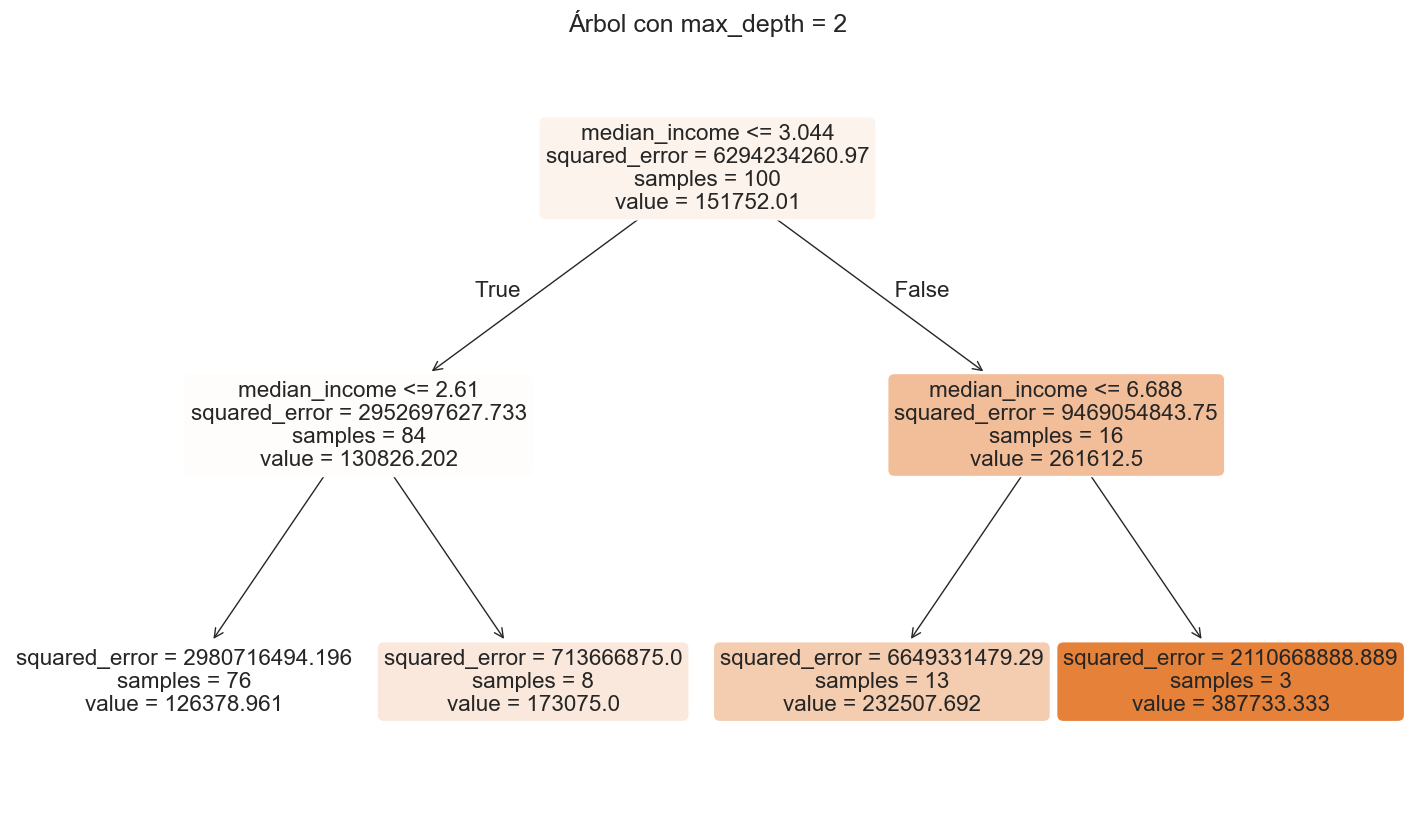

In [2]:
# Celda de configuración (la usaremos para todo el notebook)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")

# Cargamos un subconjunto de los datos para que las visualizaciones sean rápidas y claras
url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
df = pd.read_csv(url)
X_viz = df[['median_income', 'housing_median_age']].head(100) # Usamos solo 2 features y 100 muestras
y_viz = df['median_house_value'].head(100)

# --- Visualización 1: max_depth = 2 ---
tree_depth_2 = DecisionTreeRegressor(max_depth=2, random_state=42).fit(X_viz, y_viz)
plt.figure(figsize=(18, 10)) # Figura grande para este árbol
plot_tree(tree_depth_2, feature_names=X_viz.columns, filled=True, rounded=True)
plt.title("Árbol con max_depth = 2", fontsize=18)
plt.show()

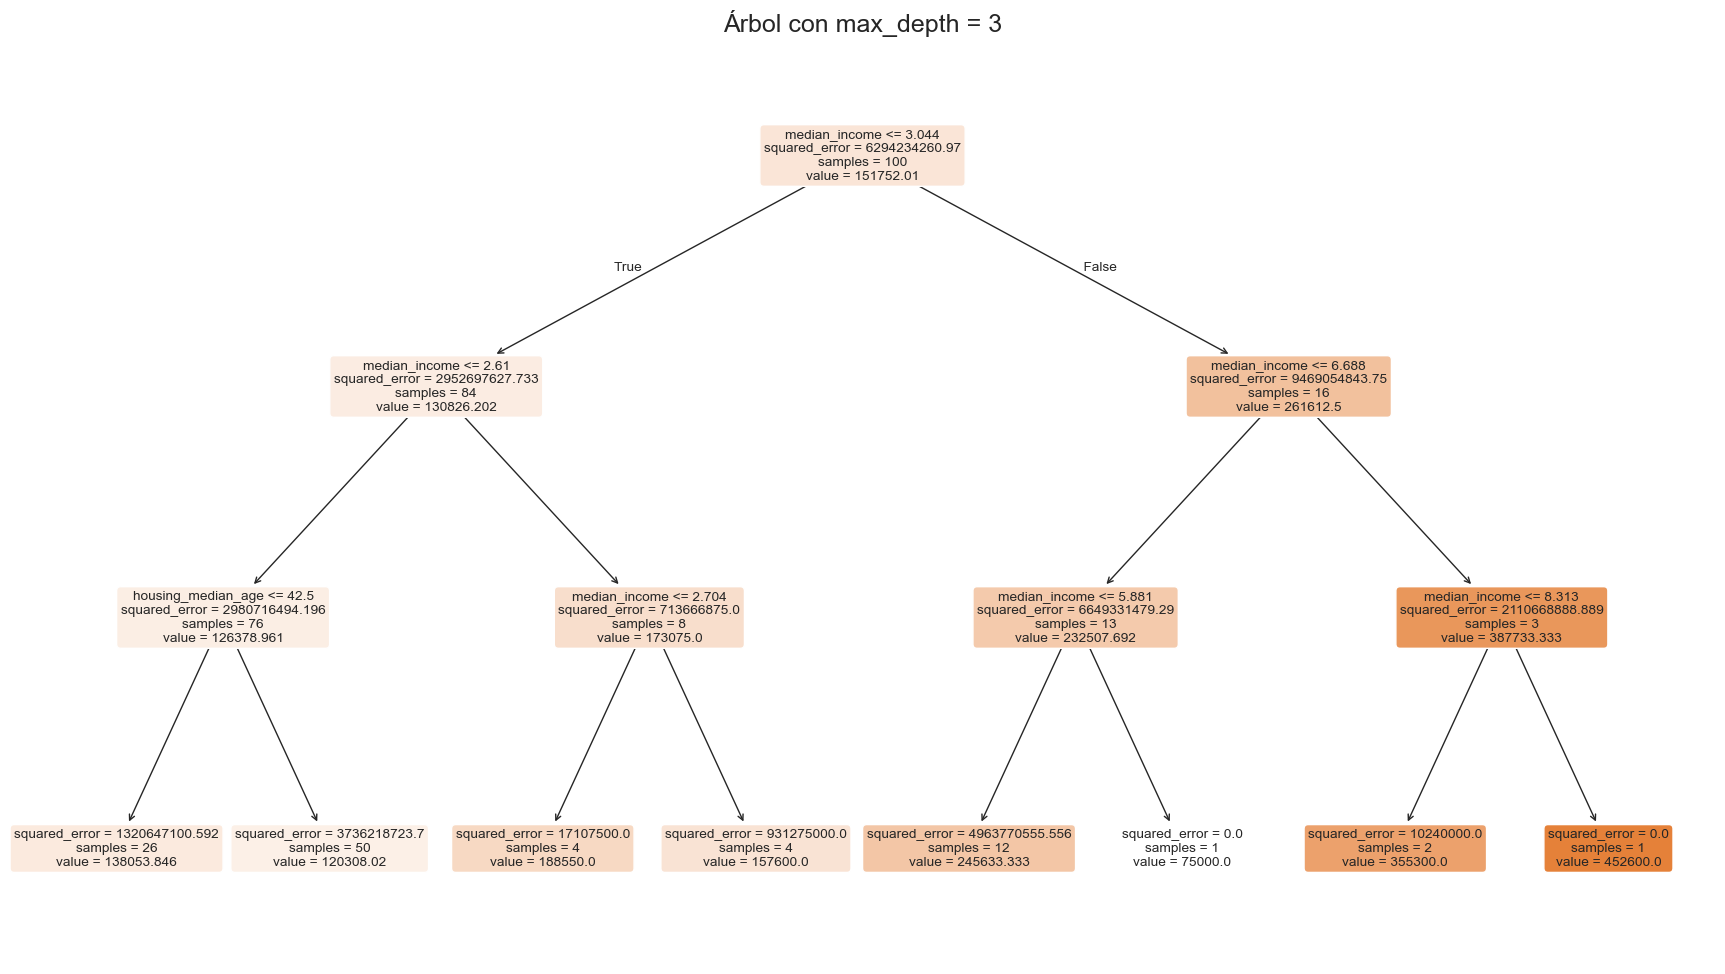

In [3]:
# --- Visualización 2: max_depth = 3 ---
tree_depth_3 = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_viz, y_viz)
plt.figure(figsize=(22, 12)) # Figura aún más grande para que quepa bien
plot_tree(tree_depth_3, feature_names=X_viz.columns, filled=True, rounded=True)
plt.title("Árbol con max_depth = 3", fontsize=18)
plt.show()

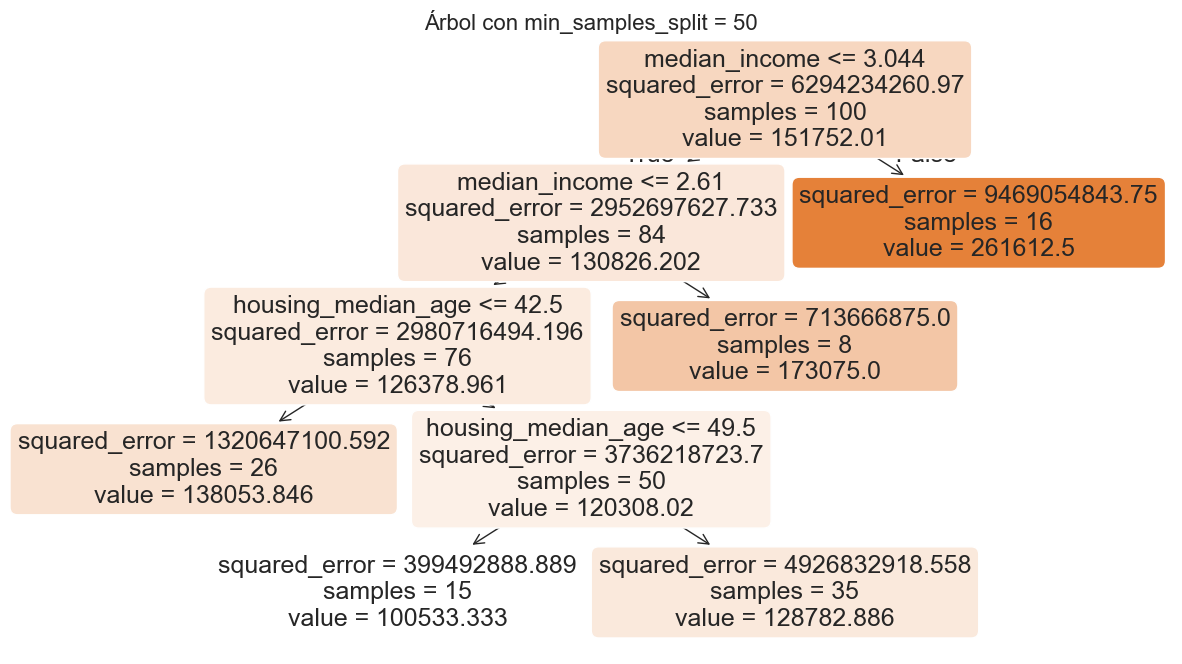

In [4]:
# --- Visualización 3: min_samples_split = 50 ---
# Si un nodo tiene menos de 50 muestras, no podrá seguir dividiéndose.
tree_split_50 = DecisionTreeRegressor(max_depth=4, min_samples_split=50, random_state=42).fit(X_viz, y_viz)
plt.figure(figsize=(15, 8))
plot_tree(tree_split_50, feature_names=X_viz.columns, filled=True, rounded=True)
plt.title("Árbol con min_samples_split = 50", fontsize=16)
plt.show()

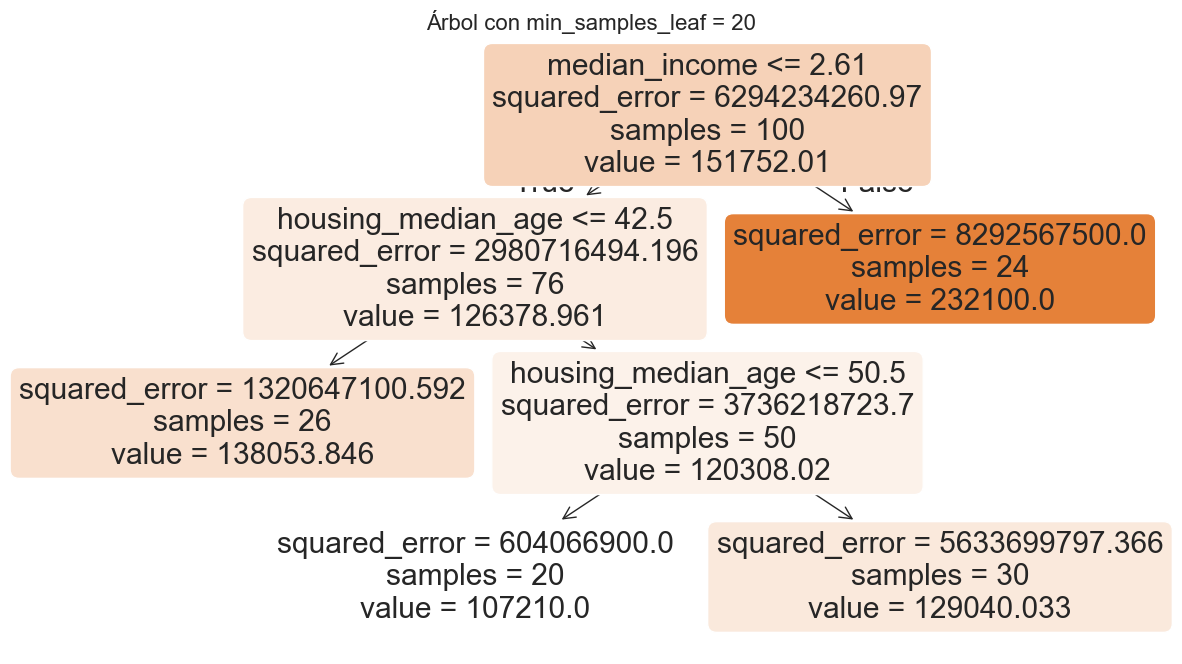

In [5]:
# --- Visualización 4: min_samples_leaf = 20 ---
# Las hojas finales deberán tener al menos 20 muestras cada una.
tree_leaf_20 = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42).fit(X_viz, y_viz)
plt.figure(figsize=(15, 8))
plot_tree(tree_leaf_20, feature_names=X_viz.columns, filled=True, rounded=True)
plt.title("Árbol con min_samples_leaf = 20", fontsize=16)
plt.show()

## 3. El Dilema: Sobreajuste vs. Subajuste

Ya hemos visto que podemos controlar la complejidad. Ahora vamos a diagnosticar el problema principal de los árboles.

-   **Árboles profundos (sin límites)**: Son tan flexibles que "memorizan" el ruido de los datos de entrenamiento. Obtienen un rendimiento perfecto en ellos, pero **generalizan muy mal** a datos nuevos. Esto es **sobreajuste (overfitting)**.
-   **Árboles muy podados (muy limitados)**: Son tan simples que no capturan ni siquiera la información importante de los datos. Fallan tanto en entrenamiento como en prueba. Esto es **subajuste (underfitting)**.

Nuestro objetivo es encontrar el **punto dulce** entre estos dos extremos.

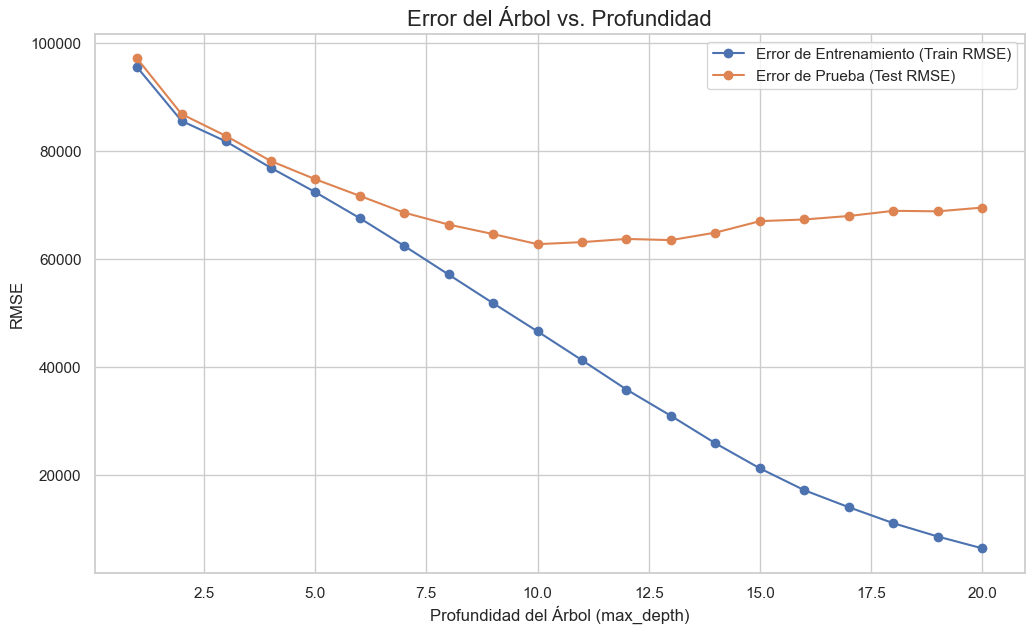

In [6]:
# --- Volvemos a nuestro dataset completo y preparado ---
df_numeric = df.select_dtypes(include=np.number)
for col in df_numeric.columns:
    if df_numeric[col].isnull().any():
        median_val = df_numeric[col].median()
        df_numeric[col] = df_numeric[col].fillna(median_val)
X = df_numeric.drop('median_house_value', axis=1)
y = df_numeric['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Visualización de error en train vs test para distintos depths ---
max_depths = range(1, 21)
train_rmses = []
test_rmses = []

for depth in max_depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    # Error en train
    y_pred_train = tree.predict(X_train)
    train_rmses.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    # Error en test
    y_pred_test = tree.predict(X_test)
    test_rmses.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

# Graficamos los resultados
plt.figure(figsize=(12, 7))
plt.plot(max_depths, train_rmses, 'o-', label='Error de Entrenamiento (Train RMSE)')
plt.plot(max_depths, test_rmses, 'o-', label='Error de Prueba (Test RMSE)')
plt.xlabel('Profundidad del Árbol (max_depth)')
plt.ylabel('RMSE')
plt.title('Error del Árbol vs. Profundidad', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Conclusión del gráfico: El error de entrenamiento baja hasta casi cero (overfitting).
# El error de prueba baja hasta un punto (el "codo" de la curva, alrededor de depth=10) y luego
# empieza a empeorar o se estanca. ¡Ese "codo" es el punto dulce que buscamos!

## EJERCICIO EN CLASE: Mini-Proyecto de Regresión con Árboles

¡Es tu turno! Vamos a aplicar todo lo que hemos aprendido en un dataset diferente: el de **costes de seguros médicos** que ya usamos en la Sesión 4. Tu objetivo es encontrar el mejor árbol de decisión posible para predecir los costes.

#### **Paso 1: Carga y Preparación de Datos**

1.  Carga el dataset de seguros desde esta URL: `https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv`
2.  Usa `pd.get_dummies()` para convertir las variables categóricas (`sex`, `smoker`, `region`) a formato numérico.
3.  Separa los datos en `X` e `y`.
4.  Divide los datos en conjuntos de entrenamiento y prueba.

#### **Paso 2: Diagnóstico del Modelo (¡Elige tu profundidad!)**

1.  Crea el **gráfico de "Error vs. Profundidad"** que hicimos antes, pero para este nuevo dataset. Prueba un rango de `max_depth` de 1 a 15.
2.  **Observa tu gráfico**: ¿En qué valor de `max_depth` la curva de error de prueba (Test RMSE) deja de bajar y empieza a aplanarse o a subir? **Escribe tu elección y una breve justificación en una celda de texto.** No hay una única respuesta correcta, ¡argumenta tu decisión!

#### **Paso 3: Entrena tu "Mejor" Árbol e Interpreta**

1.  Entrena un nuevo `DecisionTreeRegressor` usando la `max_depth` que elegiste en el paso anterior.
2.  Calcula y muestra el **RMSE final** en el conjunto de prueba para tu modelo.
3.  Obtén y grafica la **importancia de las características** (`.feature_importances_`) de tu modelo.

#### **Paso 4: Análisis y Reflexión**

Responde a esta pregunta en una celda de texto:
* Viendo tu gráfico de importancia, ¿cuál es la característica más decisiva para predecir el coste del seguro? ¿Coincide esto con lo que descubrimos en la Sesión 4 con la Regresión Lineal? ¿Por qué crees que un árbol le da tanta importancia a esa variable?

In [7]:
# --- Paso 1: Carga y Preparación ---
df = pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv')
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

print(df_encoded.head())

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


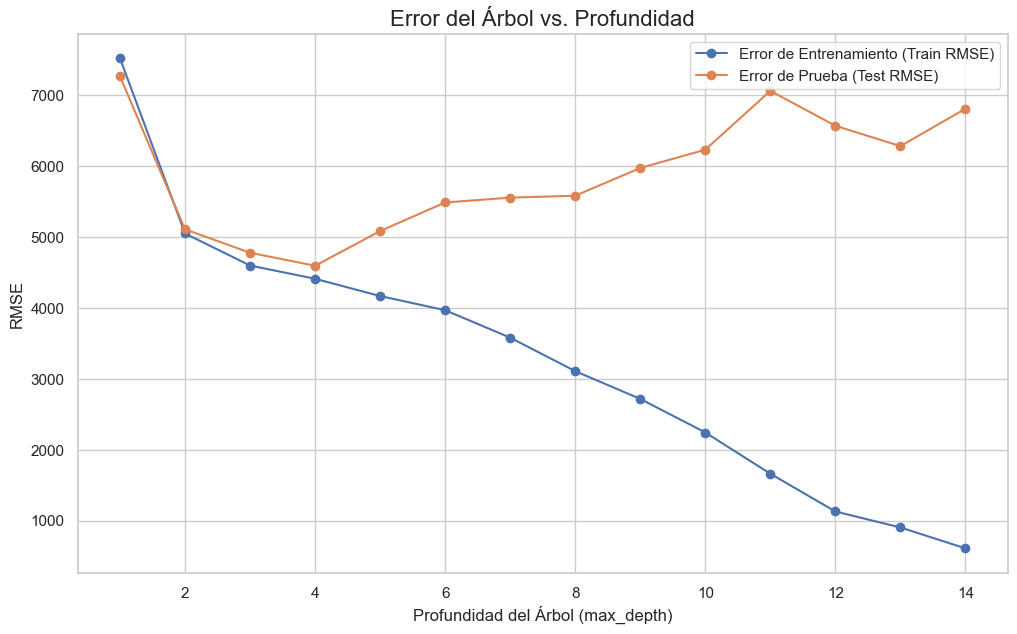

In [8]:

# --- Paso 2: Diagnóstico del Modelo ---

# --- Visualización de error en train vs test para distintos depths ---
max_depths = range(1, 15)
train_rmses = []
test_rmses = []

for depth in max_depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    # Error en train
    y_pred_train = tree.predict(X_train)
    train_rmses.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    # Error en test
    y_pred_test = tree.predict(X_test)
    test_rmses.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

# Graficamos los resultados
plt.figure(figsize=(12, 7))
plt.plot(max_depths, train_rmses, 'o-', label='Error de Entrenamiento (Train RMSE)')
plt.plot(max_depths, test_rmses, 'o-', label='Error de Prueba (Test RMSE)')
plt.xlabel('Profundidad del Árbol (max_depth)')
plt.ylabel('RMSE')
plt.title('Error del Árbol vs. Profundidad', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()


La curva empieza a subir en max depth 4. Cuando hacemos mas de 4 decisiones en el arbol los datos no tienen correlacion con la realidad, se añade demasiada complejidad y pierde capacidad predictiva

RMSE final en test (profundidad 4): 4592.76


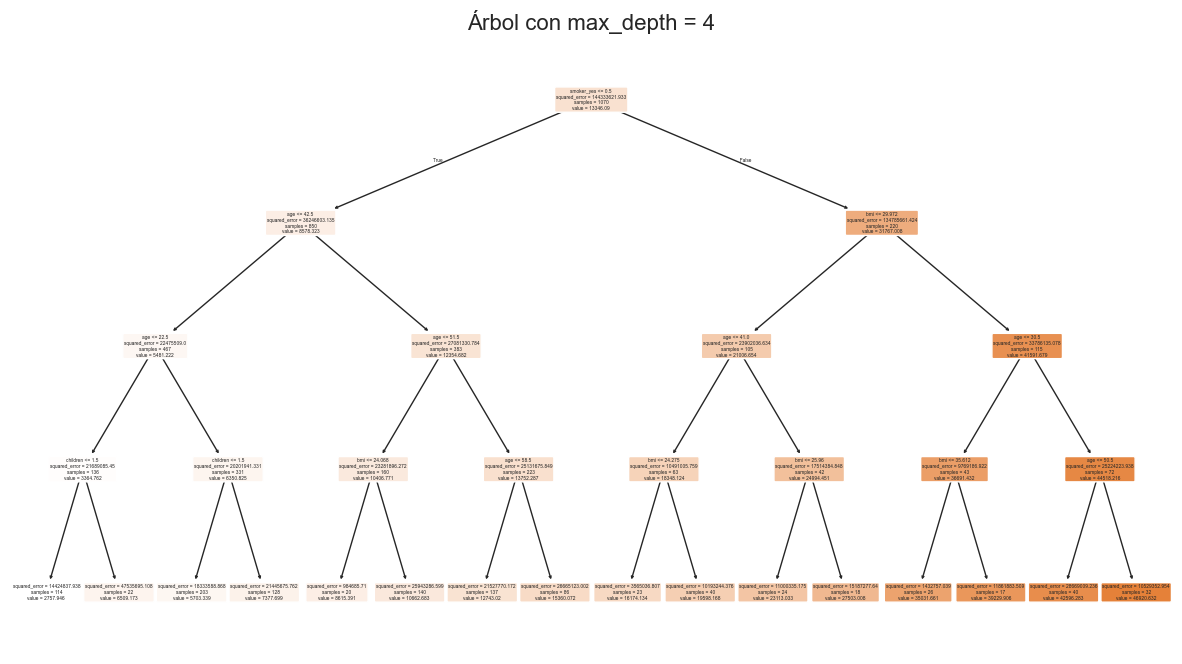

In [9]:
# --- Paso 3: Entrenamiento e Interpretación ---
tree_max_4 = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_train, y_train)

y_pred = tree_max_4.predict(X_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE final en test (profundidad 4): {rmse_final:.2f}")

plt.figure(figsize=(15, 8))
plot_tree(tree_max_4, feature_names=X_test.columns, filled=True, rounded=True)
plt.title("Árbol con max_depth = 4", fontsize=16)
plt.show()


### Mis Decisiones y Análisis

**Mi elección de `max_depth`:**
*(Escribe aquí qué profundidad elegiste y por qué, basándote en tu gráfico)*

**Análisis de la importancia de características:**
*(Escribe aquí tu respuesta a la pregunta del Paso 4)*

---
## EJERCICIO PARA CASA: Encontrando el Mejor Árbol de Decisión

En este ejercicio, realizarás el proceso completo de análisis y optimización de un árbol de decisión para el dataset de vivienda.

### **Parte 1: Diagnóstico Manual del Modelo**

Antes de usar herramientas automáticas, un buen analista debe entender cómo se comporta su modelo. Vamos a hacerlo visualizando cómo cambia el error a medida que aumenta la complejidad del árbol.

**Tareas:**
1.  **Preparación de Datos**:
    * Carga el dataset de precios de vivienda (`housing.csv`).
2.  **Análisis de Profundidad**:
    * Crea un bucle que itere sobre una lista de profundidades (`max_depths`) desde 1 hasta 20.
    * Dentro del bucle, para cada profundidad:
        * Entrena un `DecisionTreeRegressor` con esa `max_depth`.
        * Calcula el RMSE en el **conjunto de entrenamiento** y guárdalo en una lista.
        * Calcula el RMSE en el **conjunto de prueba** y guárdalo en otra lista.
3.  **Visualización y Análisis**:
    * Crea un gráfico que muestre las dos curvas de error (entrenamiento y prueba) frente a la profundidad del árbol.
    * Observa el gráfico y anota en una celda de texto el RMSE de prueba para tres profundidades clave:
        * Un árbol muy simple (`max_depth=3`).
        * El árbol del "punto dulce" (donde la curva de prueba está más baja, aprox. `max_depth=10`).
        * Un árbol claramente sobreajustado (`max_depth=20`).

### **Parte 2: Búsqueda Automática con `GridSearchCV`**

Ahora que entiendes el modelo, vamos a usar la herramienta profesional para encontrar la mejor combinación de hiperparámetros.

**Tareas:**
1.  **Define un `param_grid`**: Crea un diccionario para probar:
    * `max_depth`: con los valores `[7, 9, 11, 13]`
    * `min_samples_leaf`: con los valores `[5, 10, 15]`
    * `min_samples_split`: con los valores `[10, 20, 30]`
2.  **Configura y ejecuta `GridSearchCV`**: Usa un `DecisionTreeRegressor`, tu `param_grid`, `cv=5` y `scoring='neg_mean_squared_error'`.
3.  **Muestra los resultados**: Imprime los mejores parámetros (`.best_params_`) y el RMSE final de tu mejor modelo en el conjunto de prueba.

### **Preguntas Finales para la Reflexión**

Responde a estas preguntas en una celda de texto, usando los datos que has calculado en ambas partes del ejercicio.

1.  **Tabla Comparativa de Modelos**: Crea una pequeña tabla o lista comparando el rendimiento (RMSE en prueba) de los siguientes modelos:
    * El modelo Lasso de la sesión anterior (`RMSE ≈ $68,000`).
    * El árbol simple (`max_depth=3`).
    * El árbol del "punto dulce" (`max_depth=9`).
    * Tu árbol final optimizado con `GridSearchCV`.
2.  **Conclusión de Rendimiento**: ¿Qué modelo ha sido el ganador en términos de precisión? ¿Te ha sorprendido el resultado?
3.  **Decisión de Negocio Justificada**: Vas a presentar los resultados a un comité de dirección. Recomienda uno de los modelos de la tabla. Justifica tu elección explicando qué ganas y qué sacrificas (en términos de precisión vs. interpretabilidad) con tu decisión.

In [10]:
sns.set_theme(style="whitegrid")
# =============================================================================
# PARTE 1: DIAGNÓSTICO MANUAL DEL MODELO
# =============================================================================

print("=" * 80)
print("PARTE 1: DIAGNÓSTICO MANUAL DEL MODELO")
print("=" * 80)

# --- 1. PREPARACIÓN DE DATOS ---
print("\n📊 PASO 1: Carga y preparación de datos")
print("-" * 80)

url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
df = pd.read_csv(url)

print(f"✅ Dataset cargado: {df.shape}")
print(f"   Características: {df.shape[1] - 1}")
print(f"   Observaciones: {df.shape[0]}")

PARTE 1: DIAGNÓSTICO MANUAL DEL MODELO

📊 PASO 1: Carga y preparación de datos
--------------------------------------------------------------------------------
✅ Dataset cargado: (20640, 10)
   Características: 9
   Observaciones: 20640


In [11]:
# Procesar datos numéricos
df_numeric = df.select_dtypes(include=np.number)

# Imputar valores faltantes con la mediana
for col in df_numeric.columns:
    if df_numeric[col].isnull().any():
        median_val = df_numeric[col].median()
        df_numeric[col] = df_numeric[col].fillna(median_val)
        print(f"   • Imputados {df_numeric[col].isnull().sum()} valores en '{col}'")

# Separar X e y
X = df_numeric.drop('median_house_value', axis=1)
y = df_numeric['median_house_value']

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ División de datos:")
print(f"   Entrenamiento: {X_train.shape[0]} muestras")
print(f"   Prueba: {X_test.shape[0]} muestras")

   • Imputados 0 valores en 'total_bedrooms'

✅ División de datos:
   Entrenamiento: 16512 muestras
   Prueba: 4128 muestras


In [12]:
# --- 2. ANÁLISIS DE PROFUNDIDAD ---
print("\n" + "=" * 80)
print("📈 PASO 2: Análisis de profundidad (1 a 20)")
print("-" * 80)

max_depths = range(1, 21)
train_rmses = []
test_rmses = []



for depth in max_depths:
    # Entrenar modelo
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    
    # Predicciones en entrenamiento
    y_pred_train = tree.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    train_rmses.append(train_rmse)
    
    # Predicciones en prueba
    y_pred_test = tree.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_rmses.append(test_rmse)

print("✅ Entrenamiento completado")



📈 PASO 2: Análisis de profundidad (1 a 20)
--------------------------------------------------------------------------------
✅ Entrenamiento completado



📊 PASO 3: Visualización y análisis de resultados
--------------------------------------------------------------------------------


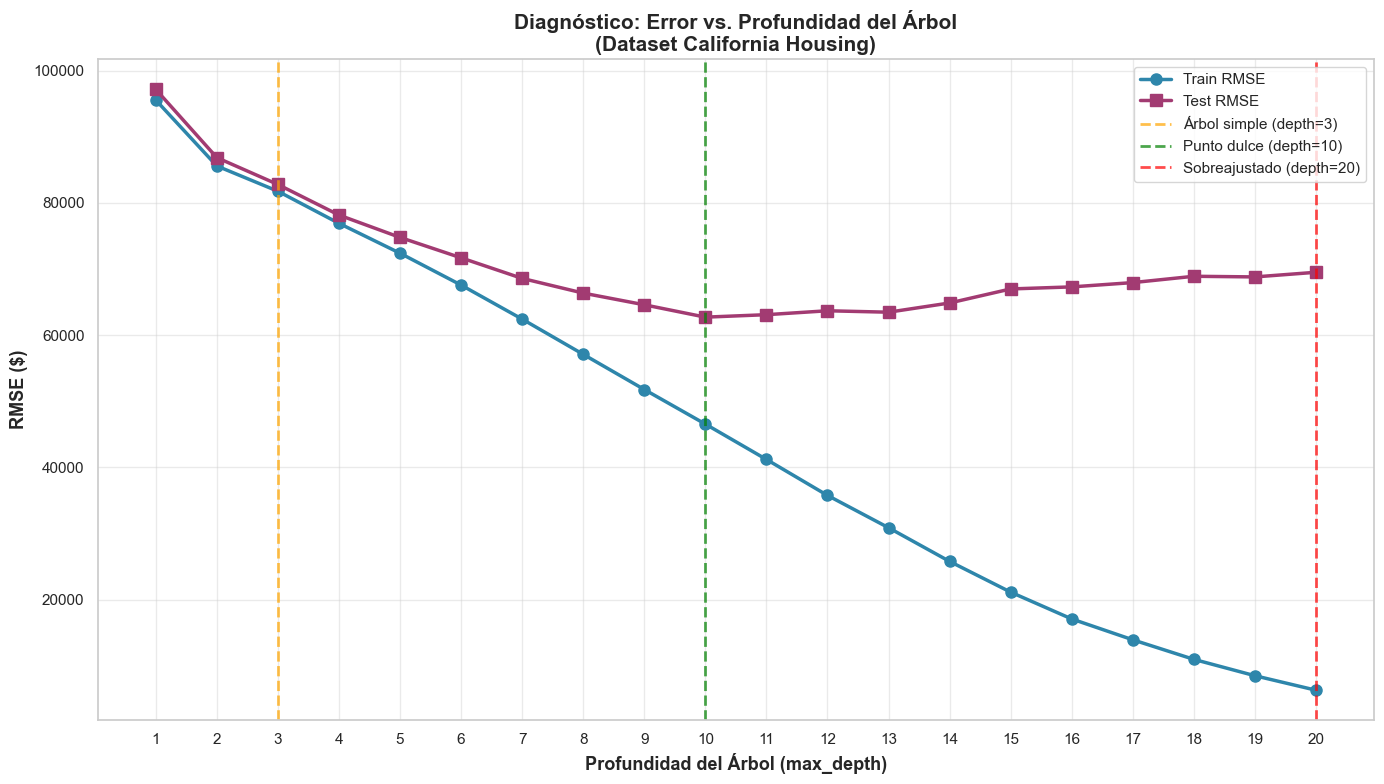


🎯 ANÁLISIS DE PUNTOS CLAVE:
--------------------------------------------------------------------------------

1️⃣  ÁRBOL SIMPLE (max_depth=3):
    • Train RMSE: $81,765.13
    • Test RMSE:  $82,787.13

2️⃣  PUNTO DULCE (max_depth=10):
    • Train RMSE: $46,562.28
    • Test RMSE:  $62,729.34

3️⃣  ÁRBOL SOBREAJUSTADO (max_depth=20):
    • Train RMSE: $6,325.50
    • Test RMSE:  $69,513.75


In [13]:
# --- 3. VISUALIZACIÓN Y ANÁLISIS ---
print("\n" + "=" * 80)
print("📊 PASO 3: Visualización y análisis de resultados")
print("-" * 80)

# Crear gráfico
plt.figure(figsize=(14, 8))
plt.plot(max_depths, train_rmses, 'o-', label='Train RMSE', 
         linewidth=2.5, markersize=8, color='#2E86AB')
plt.plot(max_depths, test_rmses, 's-', label='Test RMSE', 
         linewidth=2.5, markersize=8, color='#A23B72')

# Identificar el punto óptimo
min_test_idx = np.argmin(test_rmses)
optimal_depth = list(max_depths)[min_test_idx]

# Marcar puntos clave
plt.axvline(x=3, color='orange', linestyle='--', alpha=0.7, linewidth=2,
            label=f'Árbol simple (depth=3)')
plt.axvline(x=optimal_depth, color='green', linestyle='--', alpha=0.7, linewidth=2,
            label=f'Punto dulce (depth={optimal_depth})')
plt.axvline(x=20, color='red', linestyle='--', alpha=0.7, linewidth=2,
            label=f'Sobreajustado (depth=20)')

plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=13, fontweight='bold')
plt.ylabel('RMSE ($)', fontsize=13, fontweight='bold')
plt.title('Diagnóstico: Error vs. Profundidad del Árbol\n(Dataset California Housing)', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.4)
plt.xticks(max_depths)
plt.tight_layout()
plt.show()

# Extraer RMSE de puntos clave
rmse_simple = test_rmses[2]  # depth=3
rmse_sweet = test_rmses[min_test_idx]  # punto dulce
rmse_overfit = test_rmses[19]  # depth=20

print("\n🎯 ANÁLISIS DE PUNTOS CLAVE:")
print("-" * 80)
print(f"\n1️⃣  ÁRBOL SIMPLE (max_depth=3):")
print(f"    • Train RMSE: ${train_rmses[2]:,.2f}")
print(f"    • Test RMSE:  ${rmse_simple:,.2f}")


print(f"\n2️⃣  PUNTO DULCE (max_depth={optimal_depth}):")
print(f"    • Train RMSE: ${train_rmses[min_test_idx]:,.2f}")
print(f"    • Test RMSE:  ${rmse_sweet:,.2f}")


print(f"\n3️⃣  ÁRBOL SOBREAJUSTADO (max_depth=20):")
print(f"    • Train RMSE: ${train_rmses[19]:,.2f}")
print(f"    • Test RMSE:  ${rmse_overfit:,.2f}")



In [14]:
from sklearn.model_selection import GridSearchCV 

In [15]:
# =============================================================================
# PARTE 2: BÚSQUEDA AUTOMÁTICA CON GRIDSEARCHCV
# =============================================================================

print("\n" + "=" * 80)
print("PARTE 2: BÚSQUEDA AUTOMÁTICA CON GRIDSEARCHCV")
print("=" * 80)

# --- 1. DEFINIR PARAM_GRID ---
print("\n🔍 PASO 1: Definición de hiperparámetros a explorar")
print("-" * 80)

param_grid = {
    'max_depth': [7, 9, 11, 13],
    'min_samples_leaf': [5, 10, 15], # Evitar overfitting
    'min_samples_split': [10, 20, 30]
}

print("✅ Grid de búsqueda configurado:")
print(f"   • max_depth: {param_grid['max_depth']}")
print(f"   • min_samples_leaf: {param_grid['min_samples_leaf']}")
print(f"   • min_samples_split: {param_grid['min_samples_split']}")
print(f"   • Total de combinaciones: {len(param_grid['max_depth']) * len(param_grid['min_samples_leaf']) * len(param_grid['min_samples_split'])}")

# --- 2. CONFIGURAR Y EJECUTAR GRIDSEARCHCV ---
print("\n⚙️ PASO 2: Ejecutando GridSearchCV...")
print("-" * 80)

# Crear modelo base
tree = DecisionTreeRegressor(random_state=42)

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,  # 5 folds de validación cruzada
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Usar todos los cores disponibles
    verbose=1
)

# Ejecutar búsqueda
grid_search.fit(X_train, y_train)

print("\n✅ Búsqueda completada")

# --- 3. MOSTRAR RESULTADOS ---
print("\n" + "=" * 80)
print("📊 PASO 3: Resultados de la búsqueda")
print("-" * 80)

# Mejores parámetros
best_params = grid_search.best_params_
print("\n🏆 MEJORES HIPERPARÁMETROS:")
print(f"   • max_depth: {best_params['max_depth']}")
print(f"   • min_samples_leaf: {best_params['min_samples_leaf']}")
print(f"   • min_samples_split: {best_params['min_samples_split']}")

# RMSE en conjunto de prueba
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"\n💰 RMSE FINAL (conjunto de prueba): ${test_rmse:,.2f}")

# Comparación con modelo manual
print(f"\n📈 MEJORA vs. mejor modelo manual:")
print(f"   • Modelo manual (depth={optimal_depth}): ${rmse_sweet:,.2f}")
print(f"   • Modelo GridSearch: ${test_rmse:,.2f}")
print(f"   • Diferencia: ${rmse_sweet - test_rmse:,.2f}")


PARTE 2: BÚSQUEDA AUTOMÁTICA CON GRIDSEARCHCV

🔍 PASO 1: Definición de hiperparámetros a explorar
--------------------------------------------------------------------------------
✅ Grid de búsqueda configurado:
   • max_depth: [7, 9, 11, 13]
   • min_samples_leaf: [5, 10, 15]
   • min_samples_split: [10, 20, 30]
   • Total de combinaciones: 36

⚙️ PASO 2: Ejecutando GridSearchCV...
--------------------------------------------------------------------------------
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Búsqueda completada

📊 PASO 3: Resultados de la búsqueda
--------------------------------------------------------------------------------

🏆 MEJORES HIPERPARÁMETROS:
   • max_depth: 13
   • min_samples_leaf: 10
   • min_samples_split: 30

💰 RMSE FINAL (conjunto de prueba): $60,912.15

📈 MEJORA vs. mejor modelo manual:
   • Modelo manual (depth=10): $62,729.34
   • Modelo GridSearch: $60,912.15
   • Diferencia: $1,817.19


# Respuestas a las Preguntas Finales

## 1. Tabla Comparativa de Modelos

| Modelo | RMSE en Prueba | Descripción |
|--------|----------------|-------------|
| **Lasso (sesión anterior)** | $68,000 | Modelo lineal con regularización |
| **Árbol Simple (depth=3)** | $82,787 | Árbol muy básico, fácil de interpretar |
| **Árbol Punto Dulce (depth=10)** | $62,729 | Mejor árbol del análisis manual |
| **Árbol Optimizado (GridSearchCV)** | $60,912 | Modelo final con mejores hiperparámetros |

**Diferencias en dólares:**
- El árbol optimizado mejora **$7,088** respecto al Lasso
- El árbol optimizado mejora **$21,875** respecto al árbol simple
- El árbol optimizado mejora **$1,817** respecto al punto dulce manual

---

## 2. Conclusión de Rendimiento

**El ganador es el Árbol Optimizado con GridSearchCV** ($60,912 de RMSE).

**¿Me sorprende?** 

Sí y no:
No me sorprende que el mejor sea el gridsearch pero sí me sorprende lo mucho que se acercó el punto dulce del arbol de decisiones

---

## 3. Decisión de Negocio Justificada

### **Recomendación: Árbol Optimizado (GridSearchCV)**

**Justificación:**

**Lo que GANO:**
- **Precisión:** RMSE en prueba del modelo optimizado ≈ $60,912 — mejor que Lasso ($68,000) y que el árbol manual.
- **Generalización:** Hiperparámetros seleccionados por validación cruzada reducen el riesgo de overfitting.
- **Robustez y reproducibilidad:** GridSearchCV valida y refina el modelo de forma sistemática.
- **Interpretabilidad razonable:** Sigue siendo un árbol, por lo que las reglas son explicables frente a stakeholders y auditores.

**Lo que SACRIFICO:**
- **Complejidad ligera:** El árbol optimizado puede ser más profundo o con más reglas que un árbol muy simple, lo que dificulta una visualización completa.
- **Mantenimiento marginal:** Requiere monitorización y pruebas periódicas si se actualizan datos frecuentemente.
- **Menor simplicidad extrema:** Si la prioridad absoluta fuera la simplicidad máxima, habría que aceptar algo de pérdida de precisión.

**Resumen numérico:**
- RMSE Lasso: $68,000  
- RMSE Árbol punto dulce (manual): $62,729  
- RMSE Árbol optimizado (GridSearchCV): $60,912  
- Mejora vs Lasso: $7,088  
- Mejora vs árbol manual: $1,817

**Mensaje al comité:**

> "Propongo desplegar el árbol optimizado por GridSearchCV. Ofrece la mejor combinación entre precisión y control: mejora claramente la línea base (Lasso) y el modelo manual, mantiene interpretabilidad suficiente para auditoría y permite justificar decisiones. Si el comité prioriza simplicidad absoluta, podemos presentar una versión más simple con coste pequeño en precisión; de lo contrario, el modelo optimizado es la opción recomendada."






### Mis Resultados y Reflexiones

**Valores de RMSE del Análisis Manual:**
* RMSE con `max_depth=3`: *[Escribe aquí el valor]*
* RMSE con `max_depth=10`: *[Escribe aquí el valor]*
* RMSE con `max_depth=20`: *[Escribe aquí el valor]*

**Preguntas Finales:**
*(Responde aquí a las preguntas 1, 2 y 3)*

### Temas para Debatir en Clase

-   **¿Por qué el árbol decide dividir en un punto y no en otro?**
    * Busca el "corte" (en una variable y un valor) que más reduce la impureza de los datos. Para regresión, "impureza" se mide con el **Error Cuadrático Medio (MSE)**. El árbol elige la pregunta que crea los dos grupos de precios más homogéneos posibles.
-   **¿Qué pasa si hay outliers (valores atípicos)?**
    * Los árboles son bastante **robustos** a outliers en las **variables (X)**. Un valor extremo en una característica no afecta a las demás divisiones. Sin embargo, un outlier en la **variable objetivo (y)** sí puede afectar al promedio de la hoja final donde caiga, aunque su efecto se diluye entre las demás muestras de esa hoja.
-   **¿Qué ventajas tiene un árbol frente a una regresión lineal?**
    * **No linealidad**: Pueden capturar relaciones complejas (ej: "el precio sube hasta los 30 años de antigüedad, y luego baja").
    * **Interacciones automáticas**: No hace falta decirle que `calidad` y `área` juntas son importantes; el árbol lo descubre solo.
    * **No necesitan escalado**: Las divisiones se basan en umbrales, da igual si una variable va de 0 a 1 o de 0 a 1,000,000.
-   **¿Por qué `max_depth=1` da un resultado tan malo?**
    * Un árbol de profundidad 1 se llama "tocón" (stump). Solo puede hacer **una única pregunta**. Es el modelo más simple posible y sufre de un **subajuste** extremo (sesgo muy alto), ya que intenta explicar toda la complejidad de los precios de la vivienda con una sola regla.